In [305]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

steam_df = pd.read_csv('csv_files/games_march2025.csv')

In this file I added SQL queries and created a Database using the Steam Dataset from Kaggle. 

In [306]:
steam_df['negative'].isna().sum()

np.int64(0)

In [307]:
steam_df.loc[steam_df.duplicated()]

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent


In [308]:
steam_drop = ['notes', 'metacritic_url', 'support_url', 'support_email', 'website', 'screenshots', 'movies', 'reviews', 'score_rank', 'discount', 'peak_ccu', 'pct_pos_total', 'detailed_description', 'about_the_game', 'short_description', 'header_image', 'full_audio_languages', 'recommendations', 'packages', 'tags', 'appid']
dropped_df = steam_df.drop(columns= steam_drop)


Here I dropped a bunch of columns that I didn't use for my analysis and queries. Either because there were missing way too much data or they weren't relevent for analysis.

In [309]:
conn = sqlite3.connect('sql/video_game_db.db')

dropped_df.to_sql('steam_db', conn, if_exists='replace')

89618

In [310]:
print(pd.read_sql("SELECT name, metacritic_score FROM steam_db WHERE metacritic_score > 50 ORDER BY metacritic_score", conn))

                               name  metacritic_score
0         Five Nights at Freddy's 4                51
1                  Swag and Sorcery                51
2                          Daylight                51
3                     Silver Chains                51
4                      Bullet Witch                51
...                             ...               ...
3428                    Cobalt Core                94
3429   Mass Effect 2 (2010) Edition                94
3430      Grand Theft Auto V Legacy                96
3431                Baldur's Gate 3                96
3432  Disco Elysium - The Final Cut                97

[3433 rows x 2 columns]


In [311]:
print(pd.read_sql("SELECT SUM(windows) as windows, SUM(mac) as mac, SUM(linux) as linux FROM steam_db WHERE windows = 1 OR mac = 1 OR linux = 1", conn))

   windows    mac  linux
0    89588  17438  12627


In [312]:
print(pd.read_sql("SELECT name, release_date FROM steam_db", conn))

                                  name release_date
0                     Counter-Strike 2   2012-08-21
1                  PUBG: BATTLEGROUNDS   2017-12-21
2                               Dota 2   2013-07-09
3            Grand Theft Auto V Legacy   2015-04-13
4      Tom Clancy's Rainbow Six® Siege   2015-12-01
...                                ...          ...
89613                      Outrun Them   2024-02-29
89614      Lands of Pharaoh: Episode 1   2020-01-07
89615                       Player One   2019-10-10
89616                       DragonRoad   2025-01-25
89617               Ragtag Adventurers   2018-03-01

[89618 rows x 2 columns]


Testing some queries getting a feel of the flow of SQLite3 and exploring some possiblities for visualizations and analysis.

In [313]:
dropped_df.columns

Index(['name', 'release_date', 'required_age', 'price', 'dlc_count', 'windows',
       'mac', 'linux', 'metacritic_score', 'achievements',
       'supported_languages', 'developers', 'publishers', 'categories',
       'genres', 'user_score', 'positive', 'negative', 'estimated_owners',
       'average_playtime_forever', 'average_playtime_2weeks',
       'median_playtime_forever', 'median_playtime_2weeks',
       'num_reviews_total', 'pct_pos_recent', 'num_reviews_recent'],
      dtype='object')

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Counter-Strike 2'),
  Text(1, 0, 'Dota 2'),
  Text(2, 0, 'Grand Theft Auto V Legacy'),
  Text(3, 0, 'PUBG: BATTLEGROUNDS'),
  Text(4, 0, 'Terraria'),
  Text(5, 0, "Tom Clancy's Rainbow Six® Siege"),
  Text(6, 0, "Garry's Mod"),
  Text(7, 0, 'Black Myth: Wukong'),
  Text(8, 0, 'Rust'),
  Text(9, 0, 'Team Fortress 2')])

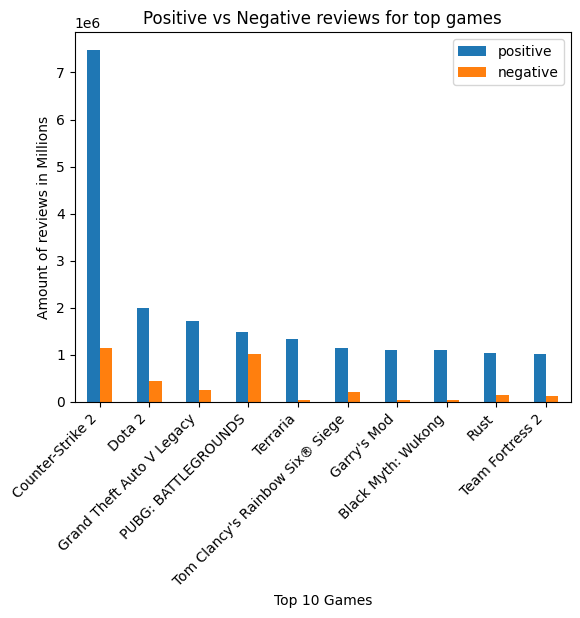

In [ ]:
pos_neg = pd.read_sql("SELECT name, positive, negative FROM steam_db ORDER BY positive DESC LIMIT 10", conn)

pos_neg.plot(kind='bar', x='name', title='Positive vs Negative reviews for top games')

plt.ylabel('Amount of reviews in Millions')
plt.xlabel('Top 10 Games')
plt.xticks(rotation=45, ha='right')



I wanted to know which games had the highest positive reviews and compare the difference of their negative review. I have found that negative reviews are only a fraction compared to the positive.

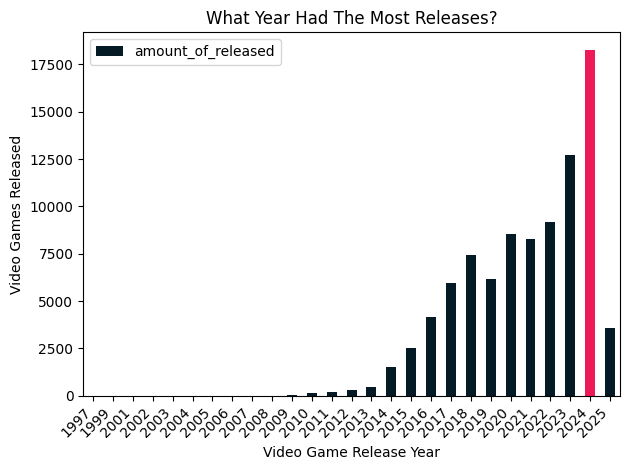

In [345]:
yearly_releases = pd.read_sql("SELECT STRFTIME('%Y', release_date) as release_year,  COUNT(release_date) AS amount_of_released FROM steam_db GROUP BY release_year" , conn)
colors = ["#041A24FF"]*len(yearly_releases)
most_releases = yearly_releases.amount_of_released.idxmax()
colors[most_releases] = "#ee1959"
yearly_releases.plot(kind='bar', x='release_year', y='amount_of_released', color = colors)

plt.title('What Year Had The Most Releases?')
plt.xlabel('Video Game Release Year')
plt.ylabel('Video Games Released')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()

I was curious how many games were released per year on steam. In this I found that most of the games were released in 2024, which makes sense due to COVID people had more time to work on indie game projects and releasing them in 2023-2024 followed by a big drop in 2025.

In [ ]:
os_games = pd.read_sql("SELECT  SUM(windows) as windows_games, SUM(mac) as mac_games, SUM(linux) as linux_games FROM steam_db WHERE windows = 1 OR mac = 1 OR linux = 1", conn)
# This was an idea of looking at what percentage of games were on different operating systems. Will be more fleshed out later.

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 [Text(0, 0, 'LoveKami -Healing Harem-'),
  Text(1, 0, 'Hatsune Miku VR'),
  Text(2, 0, 'A Sky Full of Stars 仰望夜空的星辰'),
  Text(3, 0, 'Darkness Assault'),
  Text(4, 0, 'LoveKami -Useless Goddess-'),
  Text(5, 0, 'NEKOPARA Extra'),
  Text(6, 0, "Yokai's Secret"),
  Text(7, 0, 'NEKOPARA Vol. 4'),
  Text(8, 0, 'If My Heart Had Wings'),
  Text(9, 0, 'XSOverlay'),
  Text(10, 0, 'FINAL FANTASY XIV Online'),
  Text(11, 0, 'Hiveswap Friendsim'),
  Text(12, 0, 'BuildMoreCubes'),
  Text(13, 0, 'Dota 2'),
  Text(14, 0, 'World of Warplanes'),
  Text(15, 0, 'NEKOPARA Vol. 0'),
  Text(16, 0, 'VBridger'),
  Text(17, 0, '《蜀山：初章》买断版'),
  Text(18, 0, 'Counter-Strike 2'),
  Text(19, 0, 'NEKOPARA Vol. 3')])

c:\Users\PC\Documents\Projects\video_game_sales_analysis\venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 20208 (\N{CJK UNIFIED IDEOGRAPH-4EF0}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\PC\Documents\Projects\video_game_sales_analysis\venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 26395 (\N{CJK UNIFIED IDEOGRAPH-671B}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\PC\Documents\Projects\video_game_sales_analysis\venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 22812 (\N{CJK UNIFIED IDEOGRAPH-591C}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\PC\Documents\Projects\video_game_sales_analysis\venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\PC\Documents\Projects\video_game_sales_analysis\venv\Lib\site-packages\IPython\core\events.py:96: U

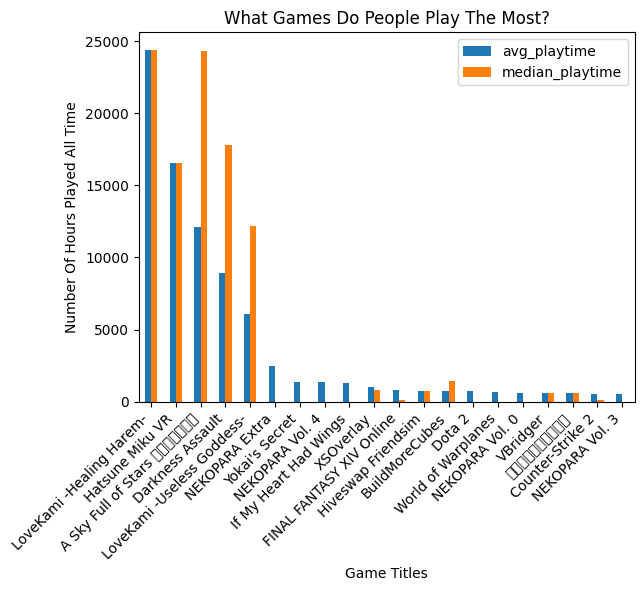

In [355]:
meta_playtime = pd.read_sql("SELECT name, ROUND(average_playtime_forever / 60, 2) AS avg_playtime, ROUND(median_playtime_forever / 60, 2) AS median_playtime FROM steam_db ORDER BY avg_playtime DESC LIMIT 20 ", conn)

meta_playtime.plot(kind='bar', x='name')

plt.title('What Games Do People Play The Most?')
plt.xlabel('Game Titles')
plt.ylabel('Number Of Hours Played All Time')
plt.xticks(rotation=45, ha='right')


Following the review analysis I was curious about playtime. I found that although Counter-Strike 2 and DOTA 2 being the highest reviewed games, they didn't have the highest amount of playtime. This chart is looking at average playtime overall and median playtime overall. Finding that people don't just play the highest reviewed games.

In [318]:
# cte_query = """WITH cte AS (
# SELECT name, metacritic_score FROM steam_db WHERE metacritic_score > 50 ORDER BY metacritic_score

# ), user_cte as (

# SELECT name, user_score FROM steam_db WHERE user_score > 50 ORDER BY user_score
# )

# SELECT cte.name, user_cte.user_score, cte.metacritic_score FROM cte
# FULL OUTER JOIN user_cte ON cte.name = user_cte.name
# WHERE user_cte.user_score IS NOT NULL OR cte.metacritic_score IS NOT NULL
# """

# steam_ratings = pd.read_sql("SELECT name, metacritic_score FROM steam_db WHERE metacritic_score IS NOT 0 ", conn)

# steam_ratings.plot(kind='scatter', x='name', y='metacritic_score')

To be fleshed out more later. Didn't have the time to fine tune this SQL query